# Hashtag Demultiplexing Report

In [193]:
import os
import yaml
import hto
import scipy
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

In [ ]:
# this cell is tagged `parameters` and will be overridden by papermill
sample_name = "test_hashtag"
path_h5ad = "../data/hashtag/adata.h5ad"
path_report = "../data/hashtag/run_report.yaml"
path_reads = "../data/hashtag/reads"

In [159]:
def remove_sequence(x):
    return [":".join(i.split("-")[0] for i in item.split(":")) for item in x]

# read anndata
adata = ad.read_h5ad(path_h5ad)
adata.var_names = remove_sequence(adata.var_names)
adata.obs["hash_id"] = remove_sequence(adata.obs["hash_id"])
adata.obs["doublet_info"] = remove_sequence(adata.obs["doublet_info"])
adata.uns["dnd"]["demux"]["thresholds"] = {k.split("-")[0]: v for k, v in adata.uns["dnd"]["demux"]["thresholds"].items()}

# read report
with open(path_report, 'r') as f:
    text = f.read().replace("\t", "  ")
    run_report = yaml.safe_load(text)

# read raw reads
barcodes = pd.read_csv(os.path.join(path_reads, "barcodes.tsv.gz"), header=None)[0]
features = pd.read_csv(os.path.join(path_reads, "features.tsv.gz"), header=None)[0]
features = [f.split("-")[0] for f in features]
matrix = scipy.io.mmread(os.path.join(path_reads, "matrix.mtx.gz")).T.tocsr()
reads = pd.DataFrame(matrix.toarray(), index=barcodes, columns=features)

In [250]:
# Combine Value + Unit for display
def format_unit(v, unit):
    if unit == "%":
        return f"{v:.1f}{unit}"
    elif unit == "K":
        return f"{v/1e3:.1f}{unit}"
    elif unit == "M":
        return f"{v/1e6:.1f}{unit}"
    elif isinstance(v, float):
        return f"{v:.1f}{unit}"
    else:
        return f"{v}{unit}"

# Conditional styling: make Value red if Warn is True, otherwise dark grey
def highlight_value(row):
    styles = []
    for col in row.index:
        if col == "Value" and row["Warn"]:
            styles.append("color:red; font-weight:bold;")
        elif col == "Source & Implication" and not row["Warn"]:
            styles.append("color:lightgrey;")
        else:
            styles.append("") # Important: Return an empty style for other cells
    return styles

def style_df(df):
    # format units
    df = df.copy()
    df.loc[:, 'Value'] = df.apply(
        lambda row: format_unit(row['Value'], row['Unit']), axis=1
    )

    # apply styling
    styled = (
        df.style
        .set_properties(**{
            "padding": "6px",
            "border": "1px solid #ccc",
            "background-color": "white",
            "color": "#333",
        })
        .set_table_styles([
            {"selector": "th", "props": [
                ("background-color", "#f7f7f7"),
                ("padding", "6px"),
                ("text-align", "center"),
                ("color", "#333")]},
            {"selector": "td.col0", "props": [("text-align", "left")]},   # Source left aligned
            {"selector": "td.col1", "props": [("text-align", "left")]}    # Implication left aligned
        ])
        .apply(highlight_value, axis=1)
        .hide(axis="index")          # hide row indices
        .hide(subset=["Warn", "Unit"], axis="columns")
    )
    return styled


In [271]:
# mapping rate
mapping_rate = run_report["Percentage mapped"]

# outlier HTO
hto_counts = adata.obs["hash_id"].value_counts()
hto_props = hto_counts / hto_counts.sum()
hto_props_singlets = hto_props[~hto_props.index.isin(["doublet", "negative"])]
hto_prop_lowest_prop = hto_props_singlets.min()
hto_prop_lowest_label = hto_props_singlets.idxmin()
hto_props_dict = hto_props.to_dict()
doublet = hto_props.get("doublet", 0)
negative = hto_props.get("negative", 0)
doublet_prop = doublet / hto_counts.sum()
negative_prop = negative / hto_counts.sum()

hash_ids = adata.var_names.tolist()
n_htos = len(hash_ids)
n_cells = adata.shape[0]

# sequencing depth
sum_umi = adata.X.sum()
sum_reads = reads.sum().sum()
reads_total = run_report["Reads processed"]
reads_per_umi = sum_reads / sum_umi
reads_in_cells = sum_reads / reads_total
unmapped_reads_q99 = np.quantile(reads.loc[adata.obs_names, "unmapped"], .95)

# low signal
unstained_cells = sum(reads.loc[adata.obs_names].sum(1) < 5)
unstained_cells_prop = unstained_cells / n_cells
signal = {}
background = {}
log_ratios = {}
for hash_id in hto_props_singlets.index:
    sub = adata.obs["hash_id"] == hash_id
    signal[hash_id] = np.mean(adata[sub, hash_id].X)
    background[hash_id] = np.mean(adata[~sub, hash_id].X)
    log_ratios[hash_id] = np.log2(signal[hash_id] / background[hash_id]) if background[hash_id] > 0 else np.nan

---

## Metrics

In [274]:
import pandas as pd
import numpy as np
from IPython.display import display

# Build metrics as a list of dicts
metrics_list = [
    {
        "Metric": "Number of Cells",
        "Value": n_cells,
        "Unit": "K",
        "Source & Implication": "Total number of cells detected. Low numbers may indicate poor capture efficiency.",
        "Warn": n_cells < 500
    },
    {
        "Metric": "Number of HTOs",
        "Value": n_htos,
        "Unit": "",
        "Source & Implication": "Total number of hashtags used. If only one, demultiplex manually.",
        "Warn": n_htos < 2,
    },
    {
        "Metric": "Total Reads",
        "Value": reads_total,
        "Unit": "M",
        "Source & Implication": "Total number of reads sequenced. Low numbers may indicate shallow sequencing.",
        "Warn": reads_total < 2e6
    },
    {
        "Metric": "Number of Reads in Cells",
        "Value": sum_reads,
        "Unit": "M",
        "Source & Implication": "Number of valid reads found in cells. Low numbers may indicate shallow sequencing, high contamination or low mapping quality.",
        "Warn": sum_reads < 1e6
    },
    {
        "Metric": "Number of UMIs",
        "Value": sum_umi,
        "Unit": "M",
        "Source & Implication": "Total number of unique molecular identifiers. Low numbers may indicate poor library complexity.",
        "Warn": sum_umi < 5e5
    },
    {
        "Metric": "Reads per UMI",
        "Value": reads_per_umi,
        "Unit": "",
        "Source & Implication": "Sequencing saturation measure. Low values may indicate shallow sequencing.",
        "Warn": reads_per_umi < 1.2
    },
    {
        "Metric": "Reads in Cells",
        "Value": reads_in_cells,
        "Unit": "%",
        "Source & Implication": "Percentage of reads from cells. Low values may indicate poor capture efficiency or high contamination.",
        "Warn": reads_in_cells < 1.2
    },
    {
        "Metric": "Mapping rate",
        "Value": mapping_rate,
        "Unit": "%",
        "Source & Implication": "Fraction of reads mapped to reference. Low may indicate contamination, wrong reference (probe barcodes), or poor library prep.",
        "Warn": mapping_rate < 20
    },
    {
        "Metric": "Unmapped Reads (Q99)",
        "Value": unmapped_reads_q99,
        "Unit": "K",
        "Source & Implication": "95-Quantile of reads not matching any barcode. High values suggest missing barcodes or contamination",
        "Warn": unmapped_reads_q99 > 1e5
    },
    {
        "Metric": f"HTO {hto_prop_lowest_label} representation",
        "Value": hto_prop_lowest_prop * 100,
        "Unit": "%",
        "Source & Implication": "Fraction of singlets for this HTO. Low values suggest unbalanced hashing or sample dropout.",
        "Warn": hto_prop_lowest_prop < (1 - doublet_prop - negative_prop) / (3 * n_htos)
    },
    {
        "Metric": "Doublets",
        "Value": f"{doublet:.1f} ({doublet_prop:.1%})",
        "Unit": "",
        "Source & Implication": "Cells classified as doublets. High levels reduce assignment accuracy.",
        "Warn": doublet_prop > 0.30
    },
    {
        "Metric": "Negative Proportion",
        "Value": f"{negative:.1f} ({negative_prop:.1%})",
        "Unit": "",
        "Source & Implication": "Cells with no clear HTO signal. High values may indicate inefficient hashing or failed capture.",
        "Warn": negative_prop > 0.30
    },
    {
        "Metric": "Unstained Cells",
        "Value": f"{unstained_cells / 1000:.1f}K ({unstained_cells_prop:.1%})",
        "Unit": "",
        "Source & Implication": "Unstained cells express <5 antibody tags. High counts suggest dropout between GEX and HTO..",
        "Warn": unstained_cells_prop > .05,
    }
]

df_metrics = pd.DataFrame(metrics_list)
df_styled = style_df(df_metrics)
display(df_styled)

Metric,Value,Source & Implication
Number of Cells,16.9K,Total number of cells detected. Low numbers may indicate poor capture efficiency.
Number of HTOs,5,"Total number of hashtags used. If only one, demultiplex manually."
Total Reads,0.1M,Total number of reads sequenced. Low numbers may indicate shallow sequencing.
Number of Reads in Cells,0.1M,"Number of valid reads found in cells. Low numbers may indicate shallow sequencing, high contamination or low mapping quality."
Number of UMIs,0.1M,Total number of unique molecular identifiers. Low numbers may indicate poor library complexity.
Reads per UMI,1.6,Sequencing saturation measure. Low values may indicate shallow sequencing.
Reads in Cells,1.0%,Percentage of reads from cells. Low values may indicate poor capture efficiency or high contamination.
Mapping rate,97.0%,"Fraction of reads mapped to reference. Low may indicate contamination, wrong reference (probe barcodes), or poor library prep."
Unmapped Reads (Q99),0.0K,95-Quantile of reads not matching any barcode. High values suggest missing barcodes or contamination
HTO A0251 representation,8.1%,Fraction of singlets for this HTO. Low values suggest unbalanced hashing or sample dropout.


---

## Warnings

In [262]:
metrics_list_warning_only = []

# Signals per HTO
for hash_id, sig in signal.items():
    metrics_list_warning_only.append({
        "Metric": f"HTO {hash_id} signal",
        "Value": sig,
        "Unit": "",
        "Source & Implication": "Average UMI count per cell. Low signal suggests weak staining or barcode dropout.",
        "Warn": sig < 20
    })

# Log2 ratios per HTO
for hash_id, lr in log_ratios.items():
    metrics_list_warning_only.append({
        "Metric": f"HTO {hash_id} log2 ratio",
        "Value": 0 if np.isnan(lr) else lr,
        "Unit": "",
        "Source & Implication": "Signal vs background separation. Low values reduce demultiplexing confidence.",
        "Warn": np.isnan(lr) or lr < 1.5
    })

df_metrics_warnings = pd.DataFrame(metrics_list_warning_only)
df_metrics_warnings = df_metrics_warnings[df_metrics_warnings["Warn"] == True]
df_styled_warnings = style_df(df_metrics_warnings)
display(df_styled_warnings)

/var/folders/cr/tgfzhd3x5cq846swrbb6hh25l39xvy/T/ipykernel_2347/2565013943.py:29: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['3.5' '3.5' '4.2' '3.1' '4.3']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[:, 'Value'] = df.apply(


Metric,Value,Source & Implication
HTO A0252 signal,3.5,Average UMI count per cell. Low signal suggests weak staining or barcode dropout.
HTO A0254 signal,3.5,Average UMI count per cell. Low signal suggests weak staining or barcode dropout.
HTO A0255 signal,4.2,Average UMI count per cell. Low signal suggests weak staining or barcode dropout.
HTO A0253 signal,3.1,Average UMI count per cell. Low signal suggests weak staining or barcode dropout.
HTO A0251 signal,4.3,Average UMI count per cell. Low signal suggests weak staining or barcode dropout.


---

## Cell Assignments

/var/folders/cr/tgfzhd3x5cq846swrbb6hh25l39xvy/T/ipykernel_2347/2030415055.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


Text(0.5, 0, '')

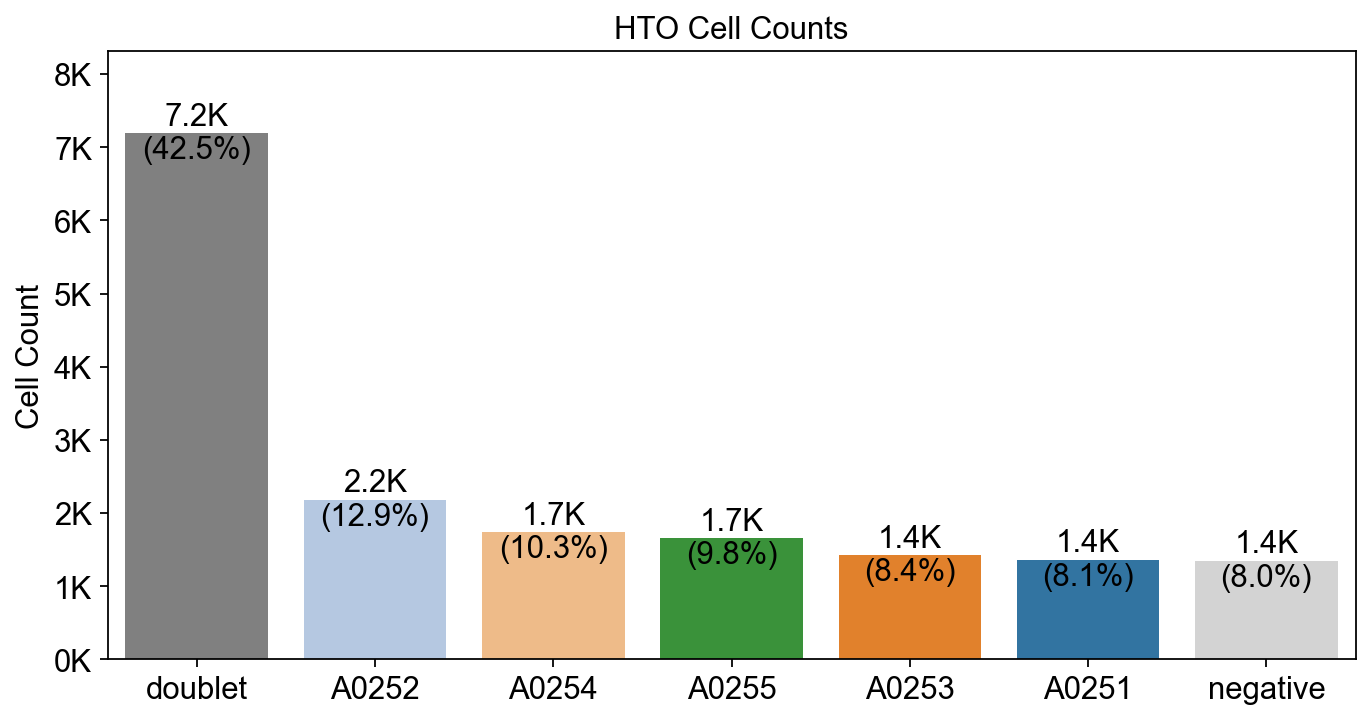

In [222]:
import matplotlib.ticker as mticks

# data
counts = adata.obs["hash_id"].value_counts()
props = counts / counts.max()

# format
order = hash_ids + ["doublet", "negative"]
cmap = dict(zip(hash_ids, sns.color_palette("tab20")))
cmap = {**cmap, "doublet": "grey", "negative": "lightgrey"}

# figure
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

# barplot
ax = sns.barplot(
    x=counts.index,
    y=counts.values,
    ax=ax,
    palette=cmap
)
ax.set_ylabel("Cell Count")
ax.set_title("HTO Cell Counts")

# annotate
for i, p in enumerate(ax.patches):
    height = p.get_height()
    count = counts.iloc[i]
    ax.text(
        x=i,
        y=count,
        s=f"{count/1e3:.1f}K\n({count / sum(counts):.1%})",
        ha="center",
        va="center",
    )

ylim = ax.get_ylim()
ax.set_ylim(ylim[0], ylim[1] * 1.1)
ax.yaxis.grid(False)
ax.yaxis.set_major_formatter(mticks.FuncFormatter(lambda x, pos: f"{x/1e3:.0f}K"))
ax.set_xlabel("")


---

## Demultiplexing with HTO-DND

Overview of the HTO-DND demultiplexing algorithm ([github](https://github.com/sail-mskcc/hto_dnd/))

1. **Logged Raw**: Logged Expression on the x-axis and density on the y-axis.
2. **Normalised Data**: Based on estimated background noise.
3. **Denoised Data**: Removed cell-by-cell variation and noise.



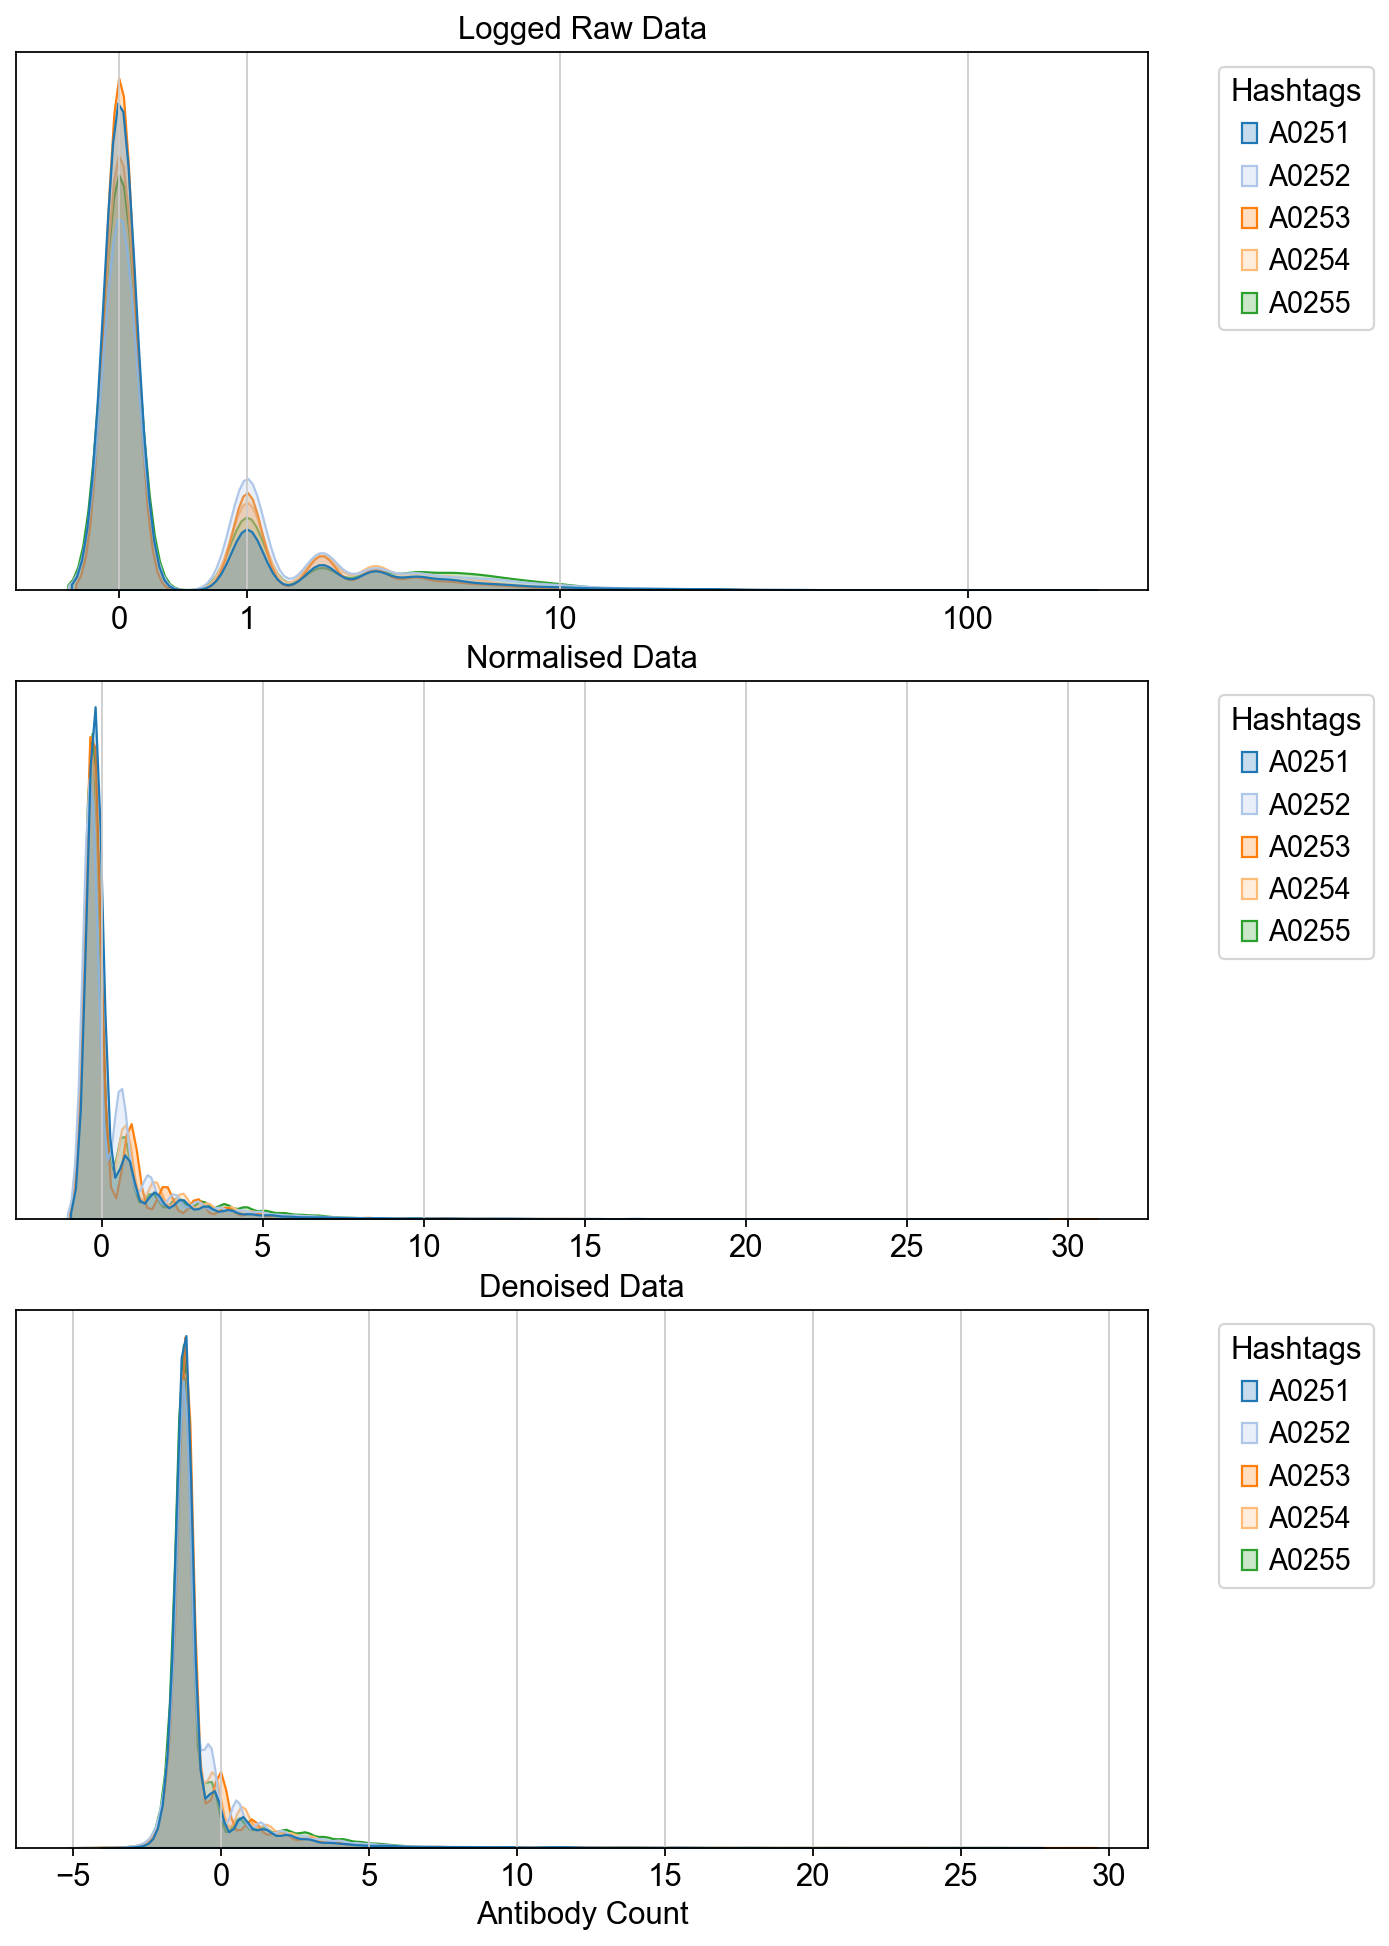

In [287]:
ax = hto.pl.distribution_stages(adata, cmap=cmap)

Overview of denoising

* **x-axis**: Shows a proxy of technical noise for each cell, represented as the center of the lower mode of the HTO expression.
* **y-axis**: Shows the normalised (1st row) and denoised (2nd row) HTO expression.

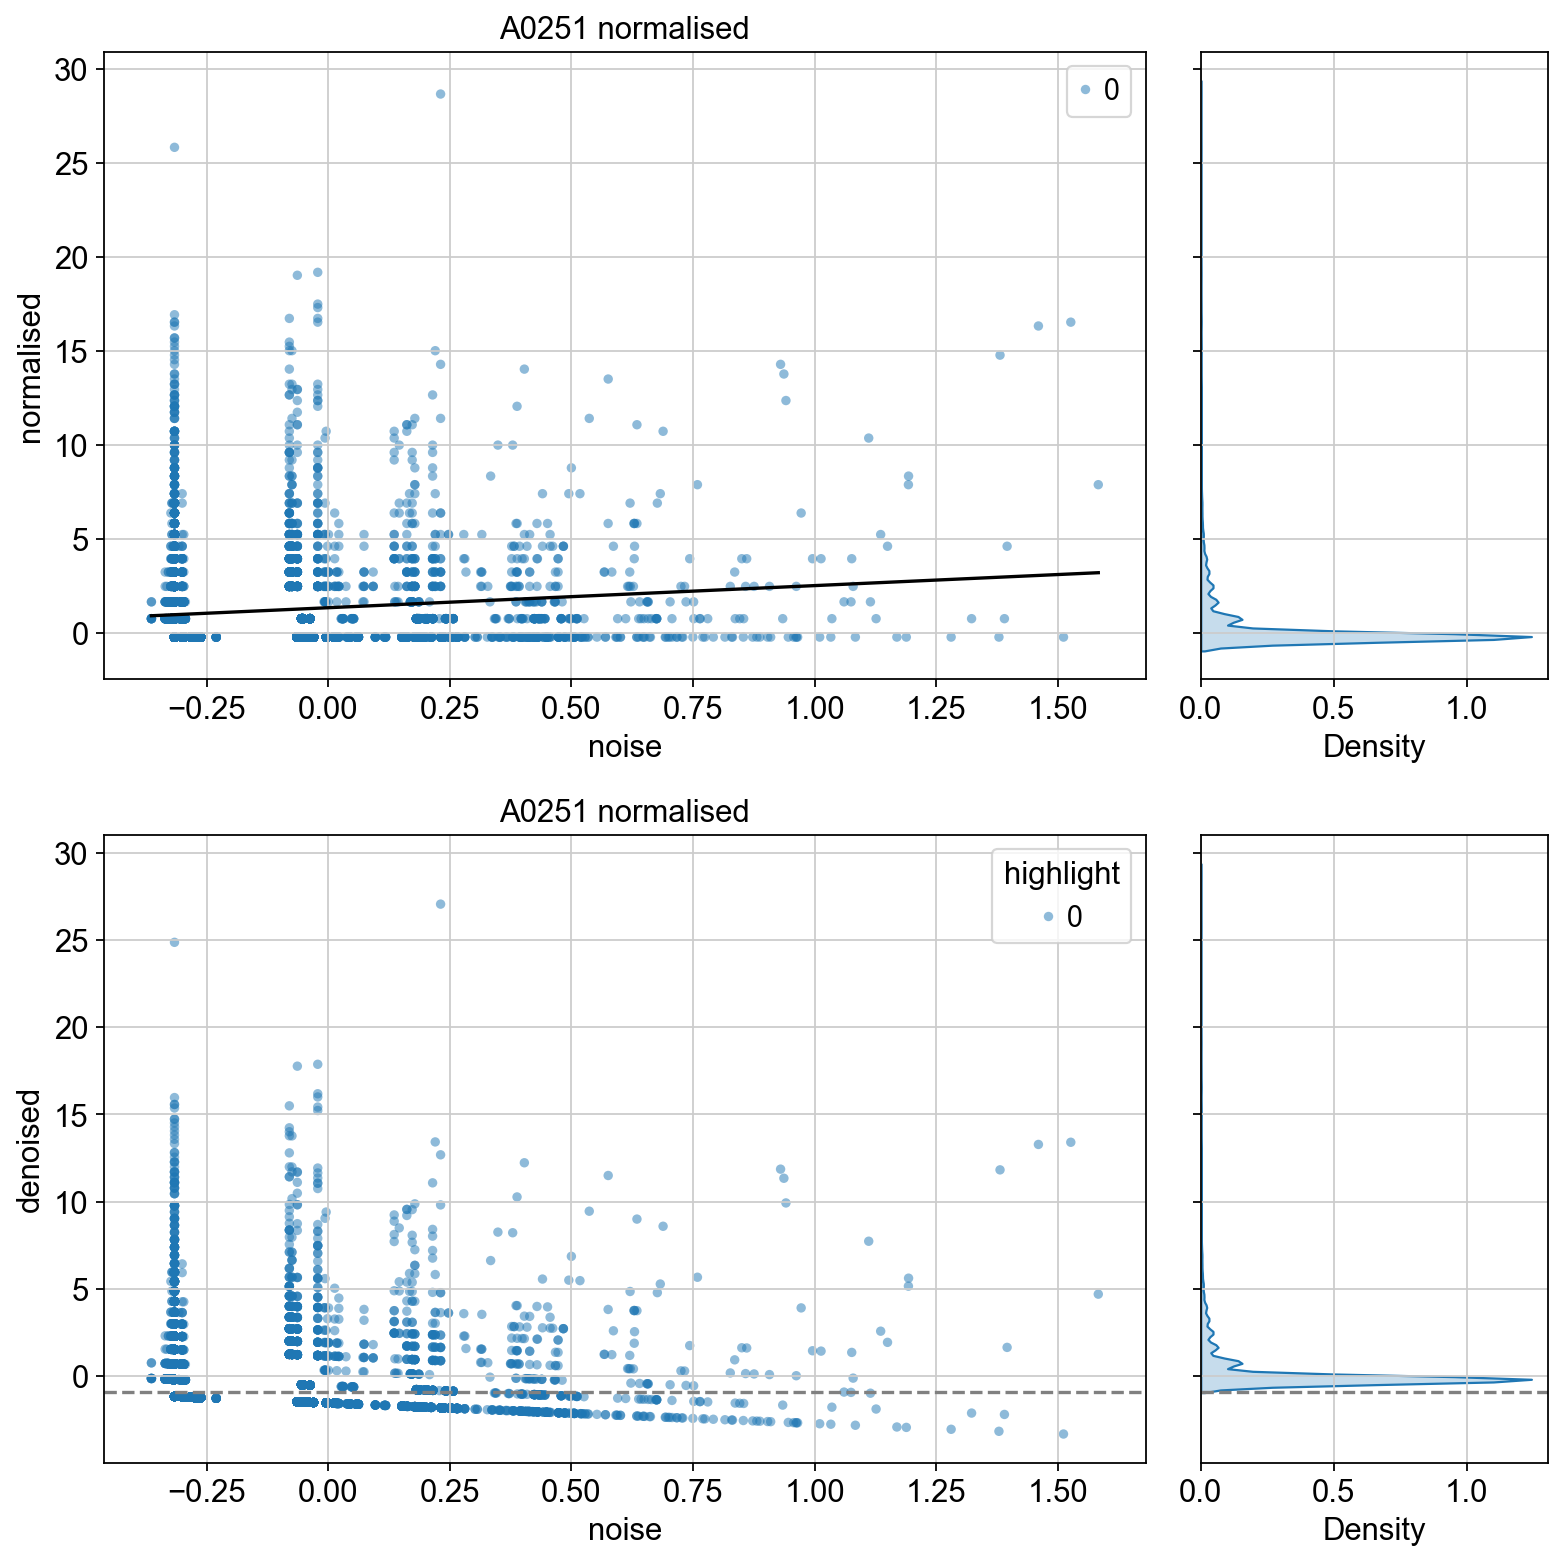

In [189]:
_, axs = hto.pl.technical_noise(adata=adata, var=0)

---

## Expression of Signal and Background

Text(0.5, 0, 'Hashtag')

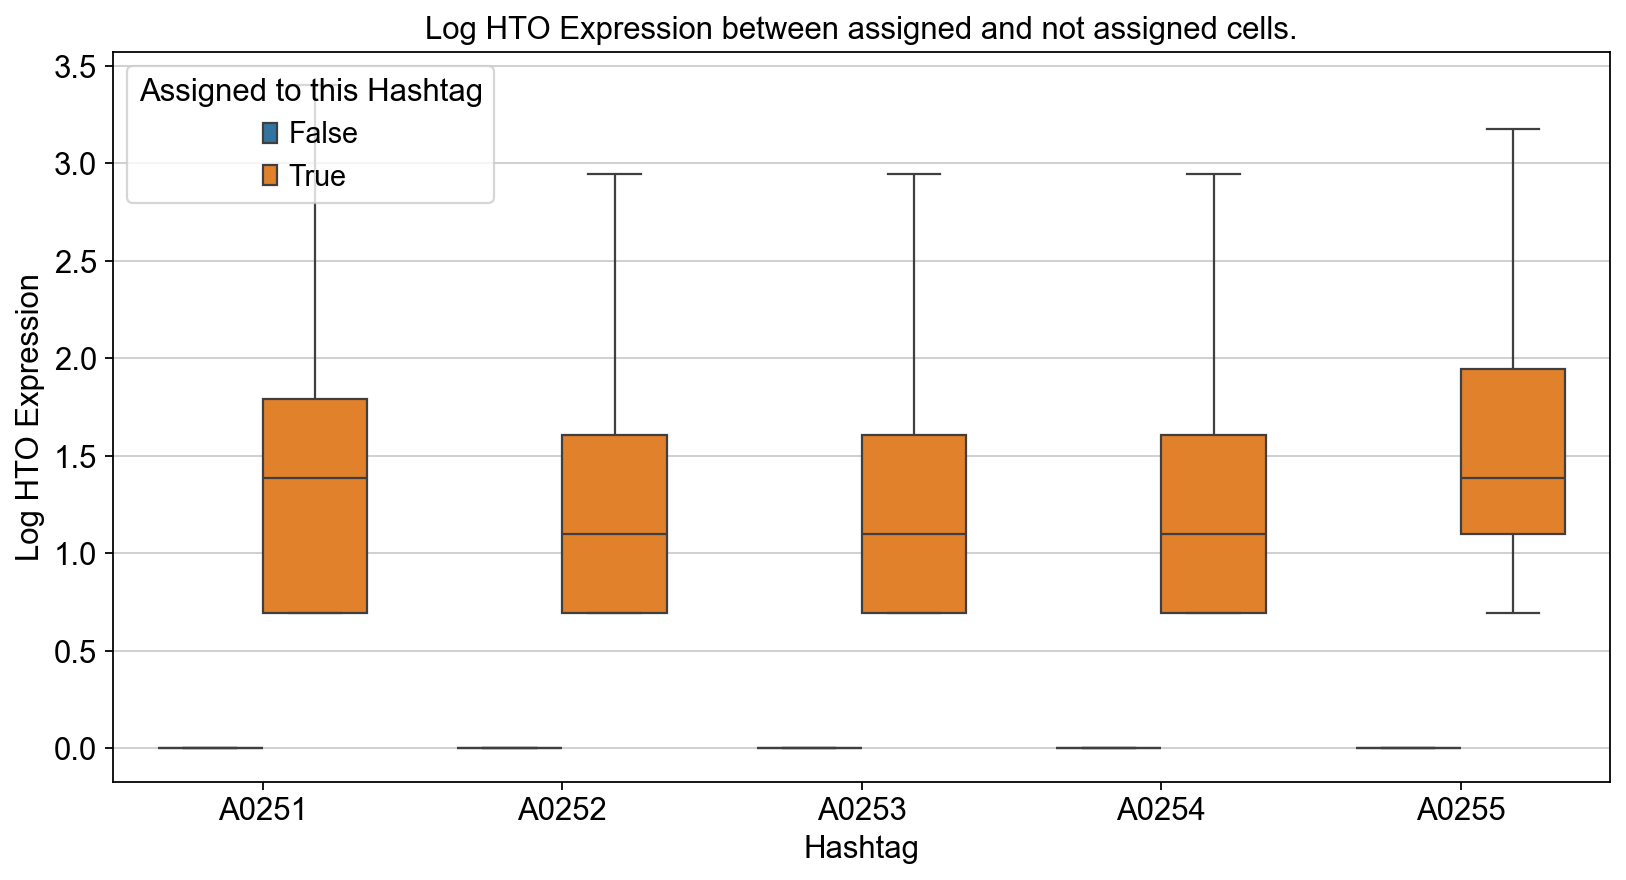

In [314]:
df = adata.to_df().join(adata.obs[["hash_id"]])

# wide to long
df_long = df.melt(id_vars="hash_id", value_name="expression", var_name="hashtag")
df_long.loc[:, "hash_id_is_hashtag"] = df_long["hash_id"] == df_long["hashtag"]
df_long.loc[:, "expression_log"] = np.log1p(df_long["expression"])
df_long_singlets = df_long[~df_long["hash_id"].isin(["doublet", "negative"])]

# plot
fig, ax = plt.subplots(figsize=(12, 6))
ax = sns.boxplot(
    df_long_singlets,
    x="hashtag",
    y="expression_log",
    hue="hash_id_is_hashtag",
    showfliers=False,
    orient="v",
    width=.7,
    ax=ax,
)

# change legend title
ax.legend(title="Assigned to this Hashtag")
ax.set_title("Log HTO Expression between assigned and not assigned cells.")
ax.set_ylabel("Log HTO Expression")
ax.set_xlabel("Hashtag")

---

## Expression of Singlets and Doublets

Text(0.5, 0, 'Category')

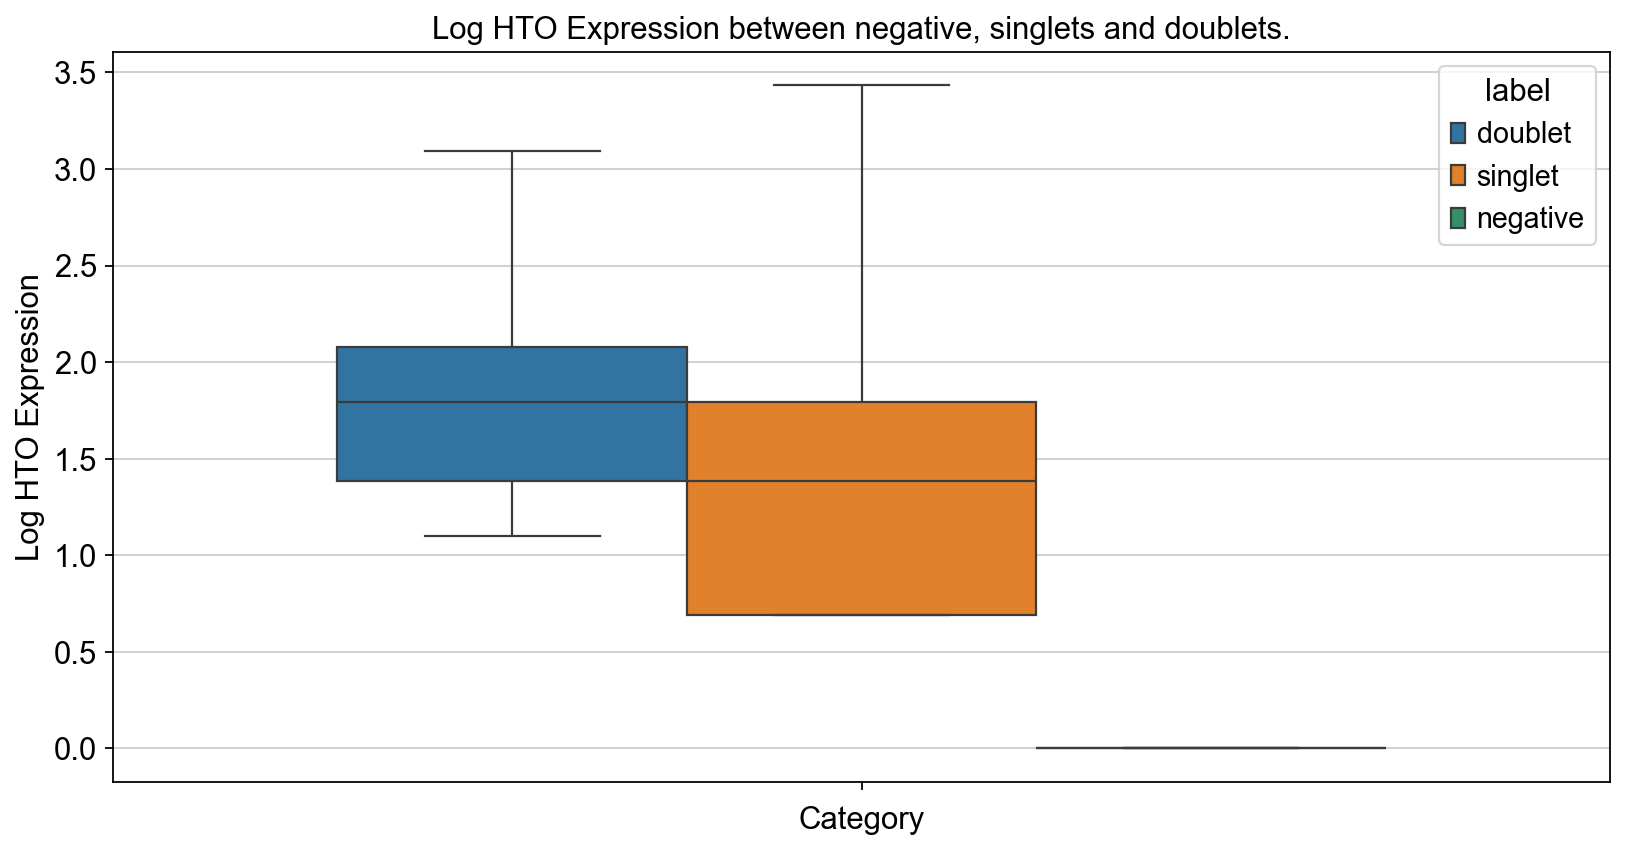

In [326]:
df = adata.to_df().sum(1).to_frame("expression").join(adata.obs["hash_id"])
df.loc[:, "label"] = df["hash_id"].apply(lambda x: x if x in ["doublet", "negative"] else "singlet")
df.loc[:, "expression_log"] = np.log1p(df["expression"])

fig, ax = plt.subplots(figsize=(12, 6))
ax = sns.boxplot(
    df,
    y="expression_log",
    hue="label",
    showfliers=False,
    orient="v",
    width=.7,
    ax=ax,
)

# change legend title
ax.set_title("Log HTO Expression between negative, singlets and doublets.")
ax.set_ylabel("Log HTO Expression")
ax.set_xlabel("Category")

---

## Data Insights

### Run Report

In [8]:
!cat $path_report

Date: 2025-09-30
Running time: 36.09 seconds
CITE-seq-Count Version: 1.4.5
Reads processed: 125000
Percentage mapped: 97
Percentage unmapped: 3
Uncorrected cells: 0
Correction:
	Cell barcodes collapsing threshold: 1
	Cell barcodes corrected: 1561
	UMI collapsing threshold: 1
	UMIs corrected: 37
Run parameters:
	Read1_paths: /cromwell-executions/Hashtag/59de4d12-acf5-41cd-995a-9bc130b1934a/call-Preprocess/Preprocess/038149de-a6f3-4b14-b4c6-b7bfefd27d41/call-CiteSeqCount/inputs/1385391274/R1.fastq.gz
	Read2_paths: /cromwell-executions/Hashtag/59de4d12-acf5-41cd-995a-9bc130b1934a/call-Preprocess/Preprocess/038149de-a6f3-4b14-b4c6-b7bfefd27d41/call-CiteSeqCount/inputs/-411560085/R2.fastq.gz
	Cell barcode:
		First position: 1
		Last position: 16
	UMI barcode:
		First position: 17
		Last position: 28
	Expected cells: 0
	Tags max errors: 2
	Start trim: 0


### UMIs

#### Raw

In [230]:
n = 5

In [232]:
adata.to_df().head(n)

,A0251,A0252,A0253,A0254,A0255
barcode,,,,,
TCCCGGACAATCCCTT-1,0,1,1,0,0
ACCCGTAAGTCCTGAG-1,0,5,0,0,1
GCTATCCTCACATTGA-1,0,0,1,8,1
CCGTTAACAAAGCTAA-1,0,2,0,0,5
AGCTATATCAGTTCCC-1,0,0,1,0,0


#### Normalised

In [233]:
adata.to_df("normalised").head(n)

,A0251,A0252,A0253,A0254,A0255
barcode,,,,,
TCCCGGACAATCCCTT-1,-0.230158,0.580839,0.884076,-0.299889,-0.306737
ACCCGTAAGTCCTGAG-1,-0.230158,3.653143,-0.293475,-0.299889,0.659054
GCTATCCTCACATTGA-1,-0.230158,-0.363276,0.884076,5.928233,0.659054
CCGTTAACAAAGCTAA-1,-0.230158,1.442748,-0.293475,-0.299889,3.801898
AGCTATATCAGTTCCC-1,-0.230158,-0.363276,0.884076,-0.299889,-0.306737


#### Denoised

In [234]:
adata.to_df("denoised").head(n)

,A0251,A0252,A0253,A0254,A0255
barcode,,,,,
TCCCGGACAATCCCTT-1,-1.235101,-0.361223,-0.046904,-1.260210,-1.300299
ACCCGTAAGTCCTGAG-1,-1.515145,2.301366,-1.612486,-1.613923,-0.695643
GCTATCCTCACATTGA-1,-1.843151,-2.194939,-0.889425,4.199904,-1.118630
CCGTTAACAAAGCTAA-1,-1.745862,-0.246577,-1.932171,-1.905334,2.149675
AGCTATATCAGTTCCC-1,-1.210269,-1.269008,-0.012497,-1.228846,-1.268276


### Reads

#### Raw

In [235]:
reads.loc[adata.obs_names[:n]]

,A0251,A0252,A0253,A0254,A0255,unmapped
barcode,,,,,,
TCCCGGACAATCCCTT-1,0,1,1,0,0,1
ACCCGTAAGTCCTGAG-1,0,5,0,0,1,0
GCTATCCTCACATTGA-1,0,0,1,8,1,0
CCGTTAACAAAGCTAA-1,0,2,0,0,5,0
AGCTATATCAGTTCCC-1,0,0,1,0,0,0
